In [61]:
# Standard Importe
import pandas as pd
import numpy as np
import os
from datetime import datetime
import requests

# Modell Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, fbeta_score

# Modelle
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
import xgboost as xgb

# Sampling for Imbalanced Data
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Modell abspeichern
import joblib


In [42]:
# csv-Datei von Git
url = "https://raw.githubusercontent.com/JanisEcker/PraxisProjekt_SAP/refs/heads/main/df.csv"

# csv laden
response = requests.get(url)
if response.status_code == 200:
    df = pd.read_csv(url)
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

In [43]:
df

,Betrag,ZeitLetzteTx,EntfernungClusterzentrum,EntfernungnaechstesGeraet,letzteHandyEntsperrung,Alter,Fraud,5311,5411,5541,5812,5912,7995,6012,5813,4111,7011
0,9820.47,8.08,14.60,72.68,2.65,41,0,1,0,0,0,0,0,0,0,0,0
1,5627.49,4.59,66.79,266.34,10.78,38,0,0,0,0,0,0,0,0,0,0,1
2,9562.64,0.49,8.23,82.54,9.12,41,0,0,0,0,0,0,0,0,1,0,0
3,5110.41,17.82,303.59,222.74,24.93,84,1,0,0,0,0,0,1,0,0,0,0
4,8687.87,0.96,959.45,299.30,35.94,78,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,6739.59,14.07,908.08,129.68,41.97,86,0,0,0,0,1,0,0,0,0,0,0
49996,5924.87,9.51,15.34,326.58,6.93,44,0,1,0,0,0,0,0,0,0,0,0
49997,2839.01,6.95,72.17,132.99,20.73,40,0,0,0,0,0,1,0,0,0,0,0
49998,8365.39,17.50,59.68,294.49,7.78,31,0,0,0,0,0,1,0,0,0,0,0


In [44]:
df.describe()

,Betrag,ZeitLetzteTx,EntfernungClusterzentrum,EntfernungnaechstesGeraet,letzteHandyEntsperrung,Alter,Fraud,5311,5411,5541,5812,5912,7995,6012,5813,4111,7011
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,5019.949972,9.961703,150.949104,250.527718,29.944553,53.460020,0.229960,0.099820,0.099240,0.100260,0.100580,0.099320,0.102360,0.099540,0.098040,0.100820,0.10002
std,2886.431852,9.986872,233.902749,144.325561,29.851264,20.748744,0.420811,0.299763,0.298987,0.300349,0.300775,0.299094,0.303124,0.299389,0.297372,0.301093,0.30003
min,0.030000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2518.922500,2.850000,31.240000,125.015000,8.680000,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5028.565000,6.900000,62.740000,250.830000,20.725000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7521.715000,13.820000,93.900000,375.690000,41.460000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9999.830000,104.480000,999.930000,499.990000,349.140000,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Betrag                     50000 non-null  float64
 1   ZeitLetzteTx               50000 non-null  float64
 2   EntfernungClusterzentrum   50000 non-null  float64
 3   EntfernungnaechstesGeraet  50000 non-null  float64
 4   letzteHandyEntsperrung     50000 non-null  float64
 5   Alter                      50000 non-null  int64  
 6   Fraud                      50000 non-null  int64  
 7   5311                       50000 non-null  int64  
 8   5411                       50000 non-null  int64  
 9   5541                       50000 non-null  int64  
 10  5812                       50000 non-null  int64  
 11  5912                       50000 non-null  int64  
 12  7995                       50000 non-null  int64  
 13  6012                       50000 non-null  int

In [46]:
# ist der df vollständig?
missing_values = df.isnull().sum()

#Fehlende Werte darstellen
missing_columns = missing_values[missing_values > 0]
print(f"Columns with missing values: {missing_columns}")

Columns with missing values: Series([], dtype: int64)


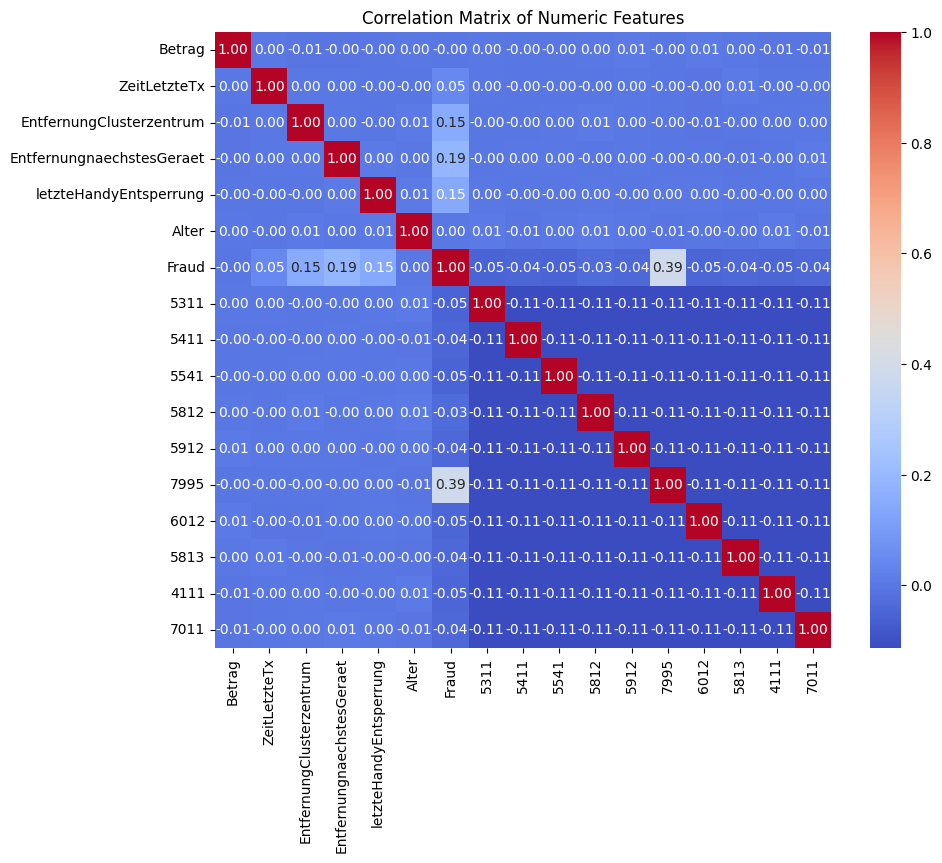

In [47]:
# Nur numerische Werte
numeric_features = df.select_dtypes(include=['number'])

# Korrelationen berechnen
correlation_matrix = numeric_features.corr()

# Korrelationsmatrix plotten
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [48]:
X = df.drop('Fraud', axis=1)
y = df['Fraud']

In [49]:
# Train-test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [50]:
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

train_percentages = train_counts / len(y_train) * 100
test_percentages = test_counts / len(y_test) * 100

# Trainingssatz
print(f"Train Set:\n"
      f"Class 0: {train_counts[0]} samples ({train_percentages[0]:.2f}%)\n"
      f"Class 1: {train_counts[1]} samples ({train_percentages[1]:.2f}%)\n")

# Testsatz
print(f"Test Set:\n"
      f"Class 0: {test_counts[0]} samples ({test_percentages[0]:.2f}%)\n"
      f"Class 1: {test_counts[1]} samples ({test_percentages[1]:.2f}%)")

Train Set:
Class 0: 34652 samples (77.00%)
Class 1: 10348 samples (23.00%)

Test Set:
Class 0: 3850 samples (77.00%)
Class 1: 1150 samples (23.00%)


In [51]:
class_names = ['No_Fraud', 'Fraud']

In [52]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, model_name: str):
    """
    Plot a confusion matrix for the model with class names (0: NoFraud, 1: Fraud).
    """
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["No_Fraud (0)", "Fraud (1)"],
        yticklabels=["No_Fraud (0)", "Fraud (1)"]
    )
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


def plot_roc_curve(y_true: np.ndarray, y_prob: np.ndarray, model_name: str):
    """
    Plot the ROC curve for the model.
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='blue')
    plt.plot([0, 1], [0, 1], linestyle='--', color='red')
    plt.title(f'ROC Curve for {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()


def save_results(model_name: str, params: str, precision: float, recall: float, f2: float, tn: int, fp: int, fn: int,
                 tp: int):
    """
    Save the evaluation results to the CSV file. If the same model and parameters exist, overwrite the row.
    """

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    new_row = {
        "timestamp": timestamp,
        "model": model_name,
        "params": params,
        "precision": precision,
        "recall": recall,
        "f2": f2,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    if not os.path.exists(RESULTS_FILE):
        pd.DataFrame([new_row]).to_csv(RESULTS_FILE, index=False)
        print(f"Results saved to {RESULTS_FILE}.")
    else:
        df = pd.read_csv(RESULTS_FILE)

        exists = ((df["model"] == model_name) & (df["params"] == params)).any()

        if exists:
            df.loc[(df["model"] == model_name) & (df["params"] == params), :] = new_row
        else:
            df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

        df.to_csv(RESULTS_FILE, index=False)
        print(f"Results updated in {RESULTS_FILE}.")


def evaluate_model(model, X_test: np.ndarray, y_test: np.ndarray, params: str, threshold: float = 0.5,
                   model_name: str = "Model"):

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    #  F2 score
    beta = 2
    f2 = (1 + beta ** 2) * (precision * recall) / ((beta ** 2 * precision) + recall) if (precision + recall) > 0 else 0

    # Plotten
    print(f"Evaluation of {model_name}")
    print("-----")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"F2 Score: {f2:.2f}")

    # Ergebnisse speichern
    save_results(model_name, params, precision, recall, f2, tn, fp, fn, tp)

    plot_confusion_matrix(y_test, y_pred, model_name)
    plot_roc_curve(y_test, y_prob, model_name)


In [53]:
clf = DecisionTreeClassifier(max_depth=4)

In [54]:
RESULTS_FILE = "model_evaluation_results.csv"

Evaluation of DecisionTreeClassifier
-----
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      3850
           1       0.68      0.36      0.47      1150

    accuracy                           0.81      5000
   macro avg       0.76      0.66      0.68      5000
weighted avg       0.80      0.81      0.79      5000

F2 Score: 0.40
Results updated in model_evaluation_results.csv.


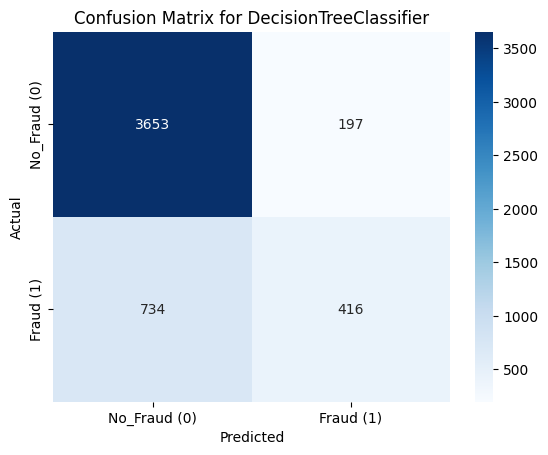

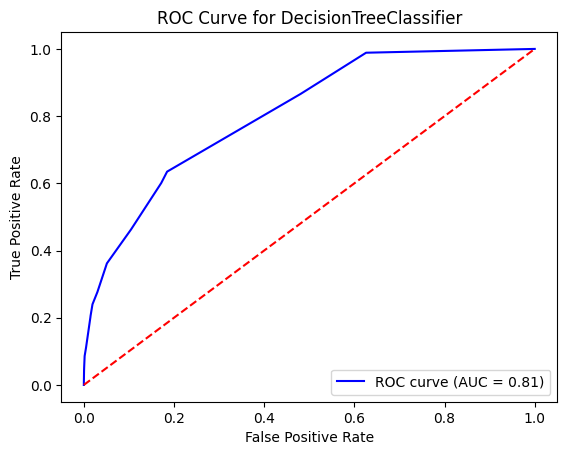

In [55]:
clf.fit(X_train, y_train)

# Vorhersagen aus Testsatz
y_pred = clf.predict(X_test)

params = {'max_depth': 4}

evaluate_model(clf, X_test, y_test, params=params, model_name="DecisionTreeClassifier")

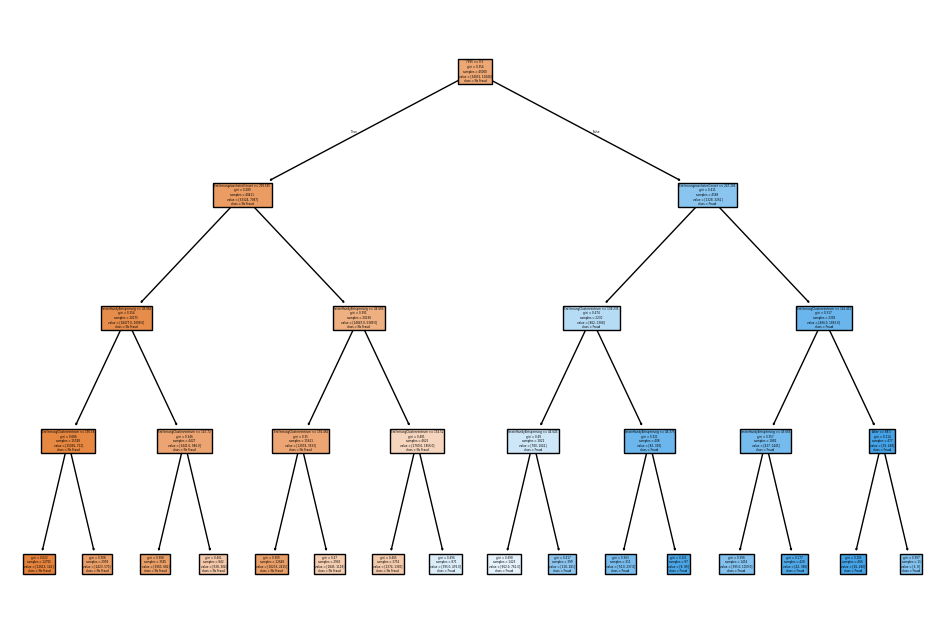

In [56]:
fig, ax = plt.subplots(figsize=(12, 8))

# Entscheidungsbaum
plot_tree(clf, feature_names=X.columns, class_names=['No Fraud', 'Fraud'], filled=True, ax=ax)
plt.show()

In [57]:
# Optional: numerische Spalten auswählen
X = df.select_dtypes(include=["float64", "int64"])

# Isolation Forest initialisieren
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # erwarteter Anteil an Anomalien
    random_state=42
)

# Modell trainieren
iso_forest.fit(X)

# Vorhersagen berechnen: -1 = Anomalie, 1 = normal
df["anomaly"] = iso_forest.predict(X)

# Score der Isolation (je niedriger, desto mehr Outlier)
df["anomaly_score"] = iso_forest.decision_function(X)

# Nur Anomalien anzeigen (optional)
anomalies = df[df["anomaly"] == -1]

# Ausgabe (optional)
print(f"Anzahl erkannter Anomalien: {len(anomalies)}")
display(anomalies.head())


Anzahl erkannter Anomalien: 2500


,Betrag,ZeitLetzteTx,EntfernungClusterzentrum,EntfernungnaechstesGeraet,letzteHandyEntsperrung,Alter,Fraud,5311,5411,5541,5812,5912,7995,6012,5813,4111,7011,anomaly,anomaly_score
36,9103.11,11.22,908.23,220.61,59.54,60,1,0,0,0,0,1,0,0,0,0,0,-1,-0.033992
45,2083.54,41.99,19.78,416.01,20.86,35,1,0,0,0,0,1,0,0,0,0,0,-1,-0.001933
66,5503.49,4.27,961.05,444.71,39.06,87,0,0,0,0,0,1,0,0,0,0,0,-1,-0.013348
78,3542.54,1.24,520.15,203.58,102.61,43,1,0,0,0,0,1,0,0,0,0,0,-1,-0.006279
102,8003.27,10.59,801.44,498.40,11.44,49,1,0,0,0,0,1,0,0,0,0,0,-1,-0.017480


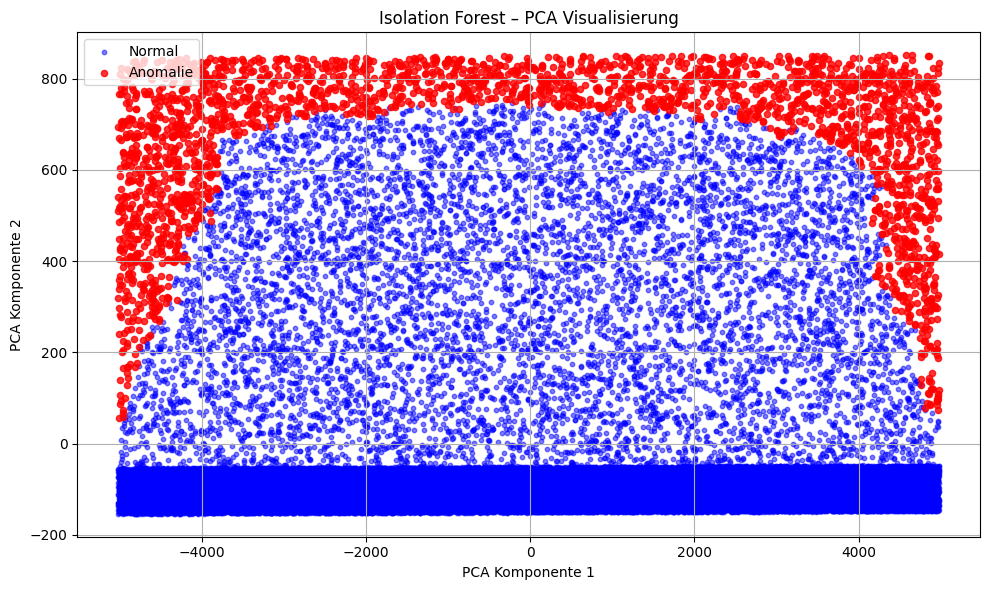

In [58]:
# Nur numerische Spalten verwenden
X_numeric = df.select_dtypes(include=["float64", "int64"])

# PCA-Reduktion auf 2 Dimensionen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric)

# Isolation Forest anwenden
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_pca)
labels = iso_forest.predict(X_pca)

# Visualisierung
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1], c='blue', label='Normal', alpha=0.5, s=10)
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1], c='red', label='Anomalie', alpha=0.8, s=20)
plt.title("Isolation Forest – PCA Visualisierung")
plt.xlabel("PCA Komponente 1")
plt.ylabel("PCA Komponente 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
df["is_anomaly"] = labels
anomalies = df[df["is_anomaly"] == -1]
display(anomalies.head())
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df["Fraud"], df["is_anomaly"] == -1))
print(classification_report(df["Fraud"], df["is_anomaly"] == -1))
df["anomaly_score"] = iso_forest.decision_function(X_pca)

,Betrag,ZeitLetzteTx,EntfernungClusterzentrum,EntfernungnaechstesGeraet,letzteHandyEntsperrung,Alter,Fraud,5311,5411,5541,5812,5912,7995,6012,5813,4111,7011,anomaly,anomaly_score,is_anomaly
4,8687.87,0.96,959.45,299.30,35.94,78,0,0,0,0,0,0,0,0,0,1,0,1,0.016538,-1
25,4746.26,7.62,962.15,456.65,23.98,48,0,0,0,1,0,0,0,0,0,0,0,1,0.016939,-1
36,9103.11,11.22,908.23,220.61,59.54,60,1,0,0,0,0,1,0,0,0,0,0,-1,-0.033992,-1
66,5503.49,4.27,961.05,444.71,39.06,87,0,0,0,0,0,1,0,0,0,0,0,-1,-0.013348,-1
87,524.44,19.91,912.69,213.53,13.82,88,0,0,0,0,0,0,0,0,0,1,0,1,0.015299,-1


[[36966  1536]
 [10534   964]]
              precision    recall  f1-score   support

           0       0.78      0.96      0.86     38502
           1       0.39      0.08      0.14     11498

    accuracy                           0.76     50000
   macro avg       0.58      0.52      0.50     50000
weighted avg       0.69      0.76      0.69     50000



In [60]:
# save model
joblib.dump(iso_forest, "isolation_forest_model.pkl")

print("Modell erfolgreich als 'isolation_forest_model.pkl' gespeichert.")

Modell erfolgreich als 'isolation_forest_model.pkl' gespeichert.
